In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [44]:
data=pd.read_excel("/Users/asmitabaul/Downloads/Gold price prediction final.xlsx")
data.head()

,Date,Gold Price,USD,Brent,Repo,CPI,Lag 1
0,2016-01-01,24943,66.30,36.00,6.75,5.69,0
1,2016-01-04,25423,66.43,36.28,6.75,5.69,24943
2,2016-01-05,25430,66.59,35.56,6.75,5.69,25423
3,2016-01-06,25756,66.70,33.89,6.75,5.69,25430
4,2016-01-07,26106,66.85,33.57,6.75,5.69,25756


In [45]:
data['Date'] = pd.to_datetime(data['Date'])
date = data.sort_values('Date')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        2514 non-null   datetime64[ns]
 1   Gold Price  2514 non-null   int64         
 2   USD         2514 non-null   float64       
 3   Brent       2514 non-null   float64       
 4   Repo        2514 non-null   float64       
 5   CPI         2514 non-null   float64       
 6   Lag 1       2514 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 137.6 KB


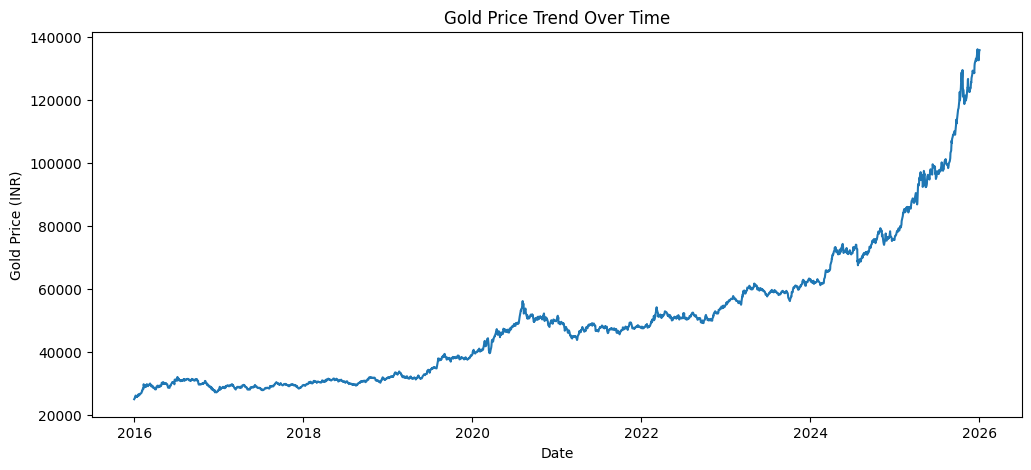

In [46]:
plt.figure(figsize=(12,5))
plt.plot(data['Date'], data['Gold Price'])
plt.xlabel("Date")
plt.ylabel("Gold Price (INR)")
plt.title("Gold Price Trend Over Time")
plt.show()

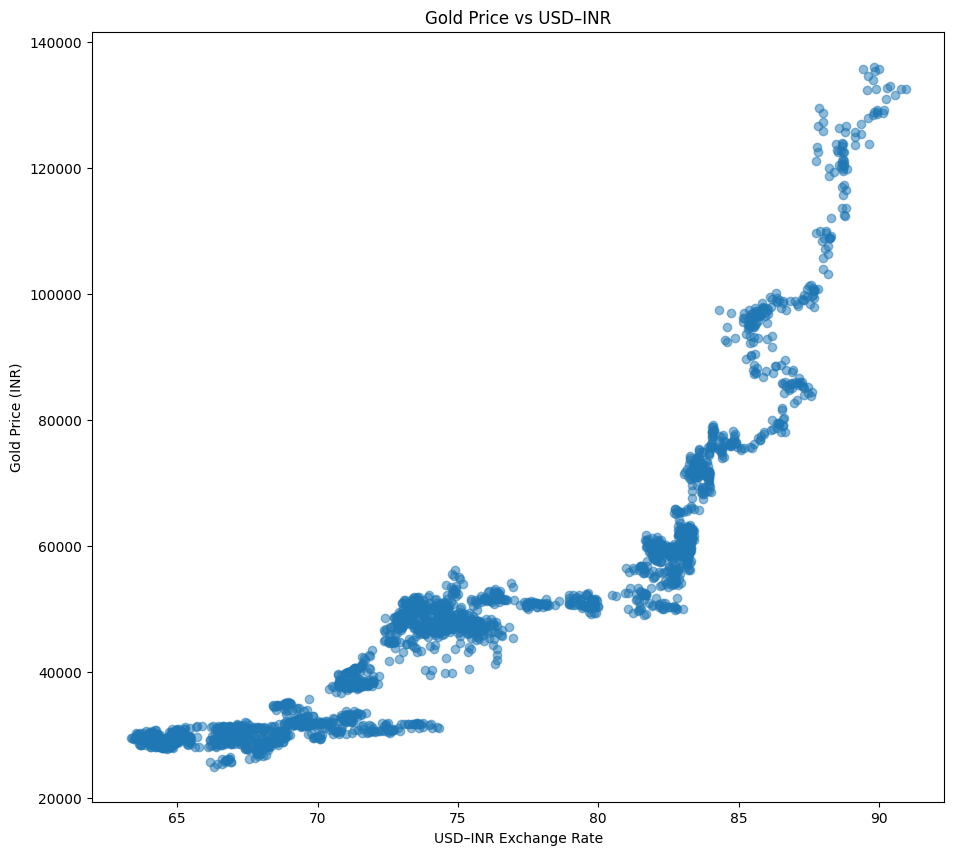

In [47]:
plt.figure(figsize=(11,10))
plt.scatter(data['USD'], data['Gold Price'], alpha=0.5)
plt.xlabel("USD–INR Exchange Rate")
plt.ylabel("Gold Price (INR)")
plt.title("Gold Price vs USD–INR")
plt.show()

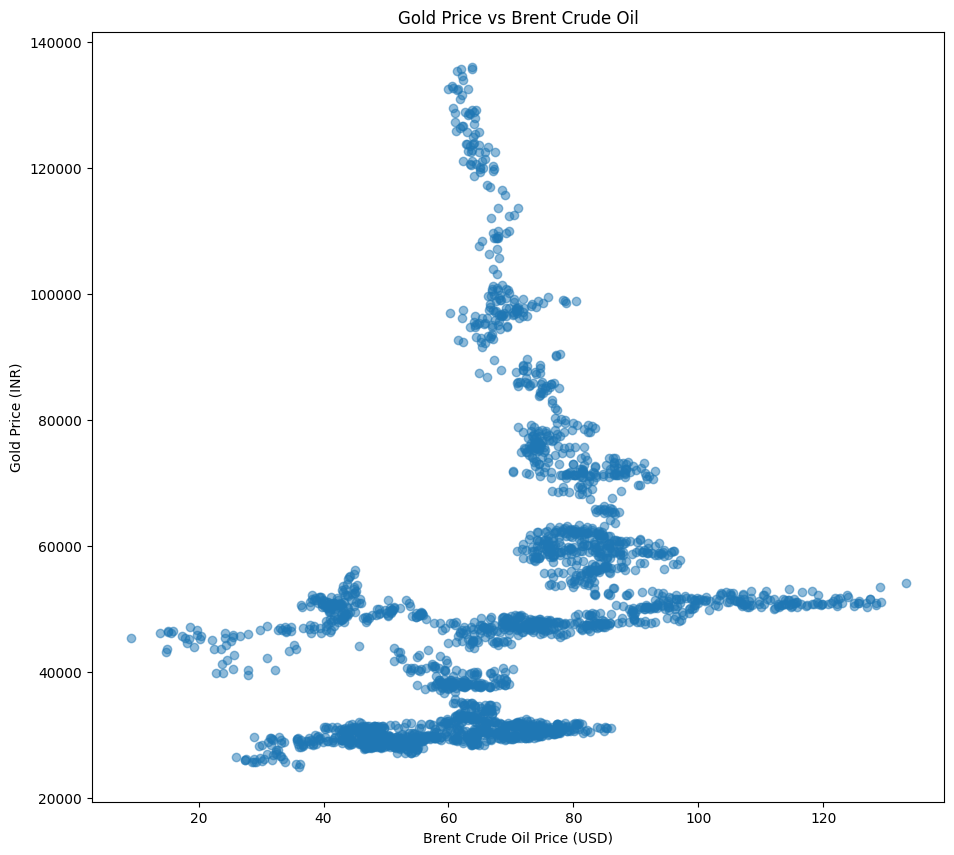

In [48]:
plt.figure(figsize=(11,10))
plt.scatter(data['Brent'], data['Gold Price'], alpha=0.5)
plt.xlabel("Brent Crude Oil Price (USD)")
plt.ylabel("Gold Price (INR)")
plt.title("Gold Price vs Brent Crude Oil")
plt.show()

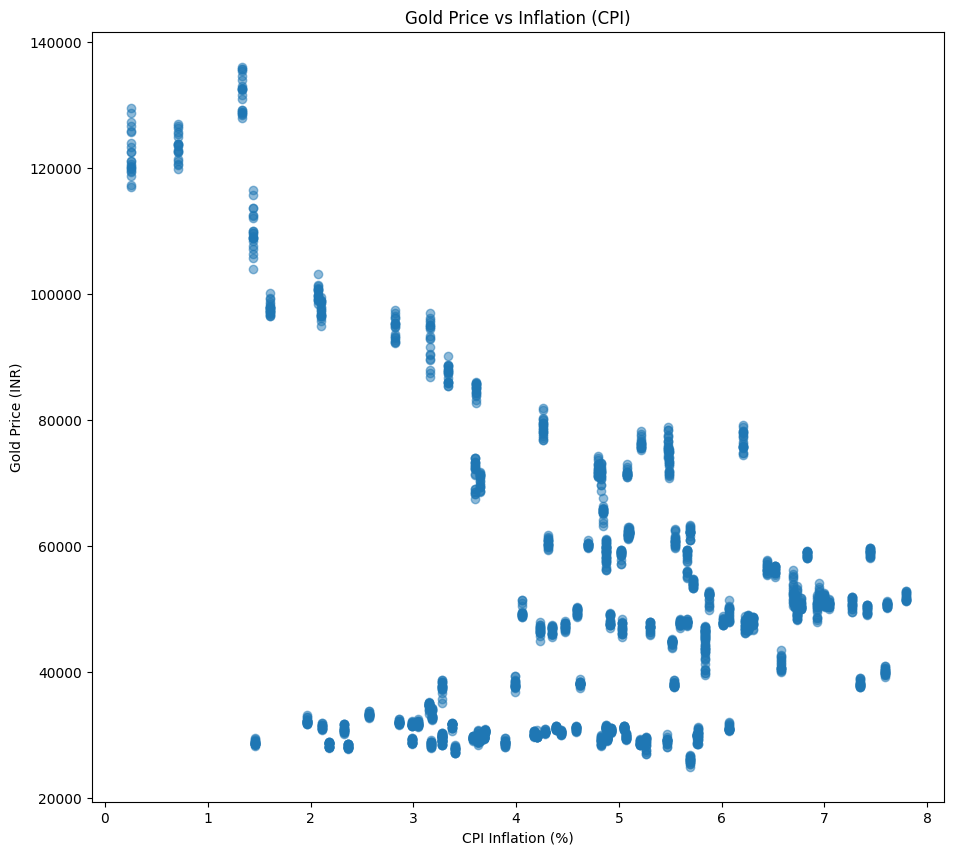

In [49]:
plt.figure(figsize=(11,10))
plt.scatter(data['CPI'], data['Gold Price'], alpha=0.5)
plt.xlabel("CPI Inflation (%)")
plt.ylabel("Gold Price (INR)")
plt.title("Gold Price vs Inflation (CPI)")
plt.show()

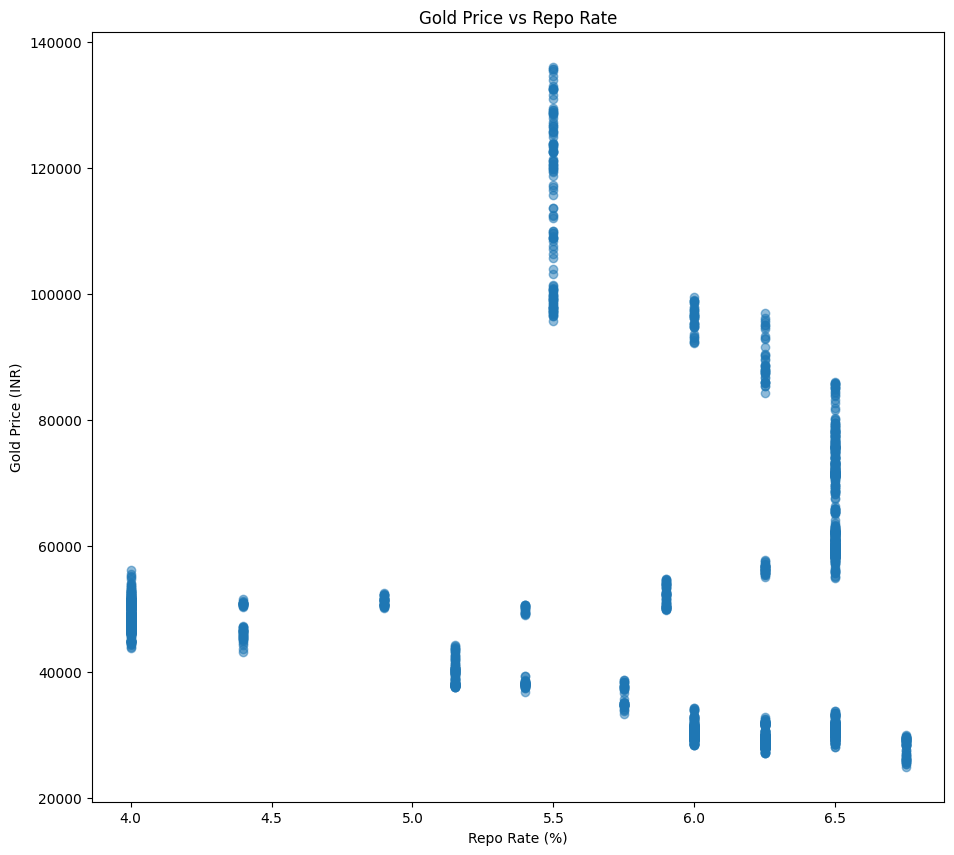

In [50]:
plt.figure(figsize=(11,10))
plt.scatter(data['Repo'], data['Gold Price'], alpha=0.5)
plt.xlabel("Repo Rate (%)")
plt.ylabel("Gold Price (INR)")
plt.title("Gold Price vs Repo Rate")
plt.show()

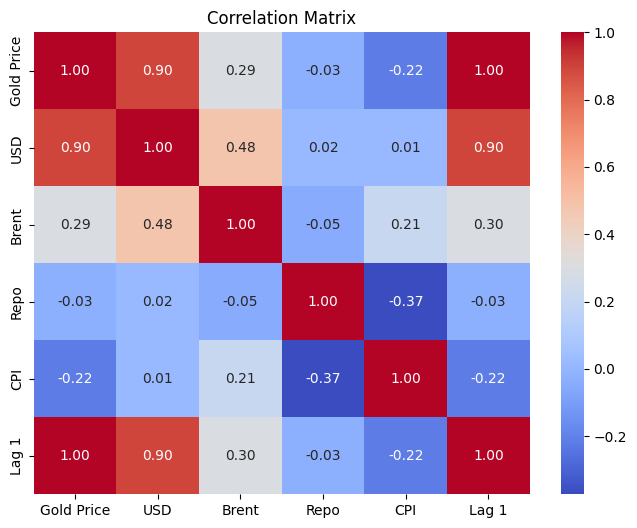

In [51]:
plt.figure(figsize=(8,6))
corr = data.drop(columns=['Date']).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [52]:
x = data.drop(columns=['Date', 'Gold Price'])
y = data['Gold Price']
print(x)
print(y)

         USD  Brent  Repo   CPI   Lag 1
0     66.300  36.00  6.75  5.69       0
1     66.430  36.28  6.75  5.69   24943
2     66.590  35.56  6.75  5.69   25423
3     66.700  33.89  6.75  5.69   25430
4     66.850  33.57  6.75  5.69   25756
...      ...    ...   ...   ...     ...
2509  89.814  63.70  5.50  1.33  135799
2510  89.900  63.10  5.50  1.33  136104
2511  89.770  62.30  5.50  1.33  132595
2512  89.871  61.35  5.50  1.33  133974
2513  90.014  61.98  5.50  1.33  135454

[2514 rows x 5 columns]
0        24943
1        25423
2        25430
3        25756
4        26106
         ...  
2509    136104
2510    132595
2511    133974
2512    135454
2513    135793
Name: Gold Price, Length: 2514, dtype: int64


In [53]:
split_date = "2022-01-01"

x_train = x[data['Date'] < split_date]
x_test  = x[data['Date'] >= split_date]

y_train = y[data['Date'] < split_date]
y_test  = y[data['Date'] >= split_date]

In [54]:
lr = LinearRegression()
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)

print("Linear Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", mean_squared_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))

Linear Regression Results:
MAE: 5827.011137800653
RMSE: 51073096.50336342
R²: 0.8867533045332846


In [55]:
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)

y_pred_ridge = ridge.predict(x_test)

print("Ridge Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", mean_squared_error(y_test, y_pred_ridge))
print("R²:", r2_score(y_test, y_pred_ridge))

Ridge Regression Results:
MAE: 5770.281951438105
RMSE: 50125031.58211597
R²: 0.8888554919229236


In [56]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print("Random Forest Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", mean_squared_error(y_test, y_pred_rf))
print("R²:", r2_score(y_test, y_pred_rf))

Random Forest Results:
MAE: 17949.268141507353
RMSE: 744897749.9580338
R²: -0.6516955974616425


In [57]:
xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

print("XGBoost Results")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", mean_squared_error(y_test, y_pred_xgb))
print("R²:", r2_score(y_test, y_pred_xgb))

XGBoost Results
MAE: 21385.978515625
RMSE: 893331584.0
R²: -0.9808245897293091


In [58]:
new_data = pd.DataFrame({
    "USD": [91.0],
    "Brent": [70.0],
    "Repo": [5.50],
    "CPI": [2.75],
    "Lag 1": [157800]
})
x.columns


Index(['USD', 'Brent', 'Repo', 'CPI', 'Lag 1'], dtype='object')

In [59]:
print("Linear Regression Prediction:", lr.predict(new_data))
print("Ridge Regression Prediction:", lr.predict(new_data))

Linear Regression Prediction: [136333.97107634]
Ridge Regression Prediction: [136333.97107634]


In [61]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Random Forest", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    "RMSE": [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_xgb)
    ],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,5827.011138,5.107310e+07,0.886753
1,Ridge Regression,5770.281951,5.012503e+07,0.888855
2,Random Forest,17949.268142,7.448977e+08,-0.651696
3,XGBoost,21385.978516,8.933316e+08,-0.980825


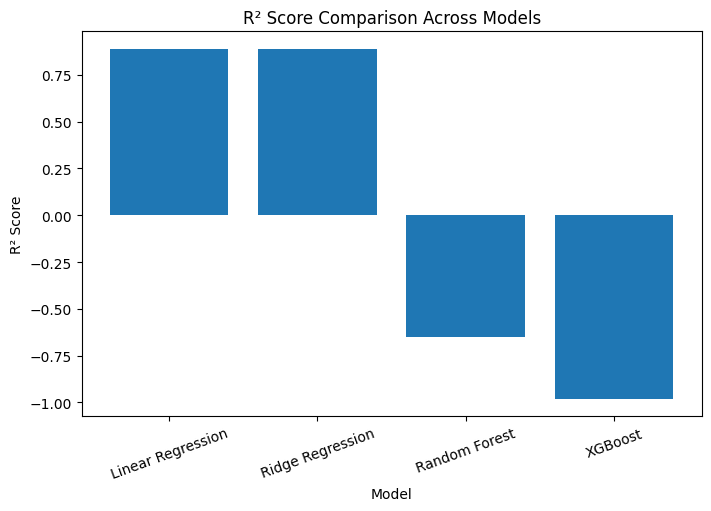

In [62]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["R2"])
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("R² Score Comparison Across Models")
plt.xticks(rotation=20)
plt.show()

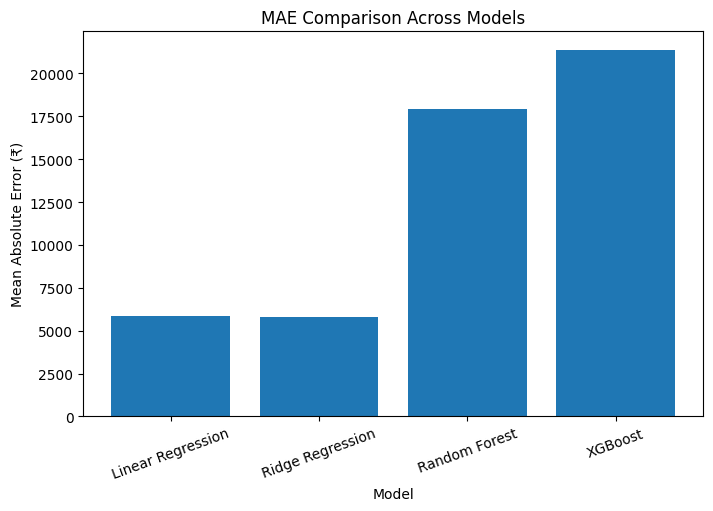

In [63]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["MAE"])
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (₹)")
plt.title("MAE Comparison Across Models")
plt.xticks(rotation=20)
plt.show()

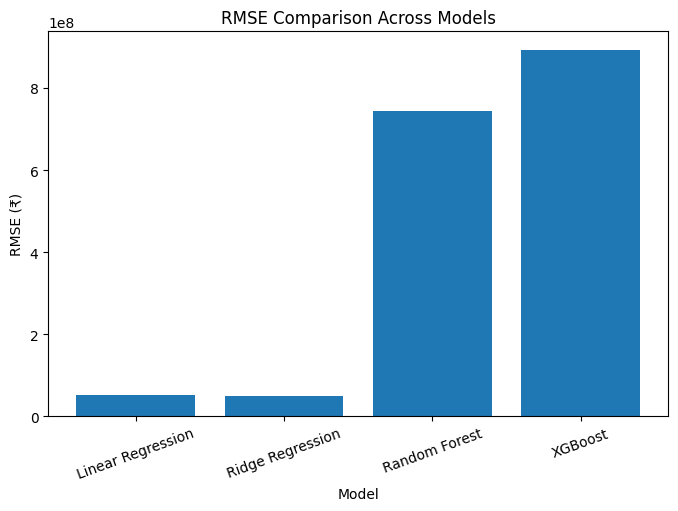

In [64]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["RMSE"])
plt.xlabel("Model")
plt.ylabel("RMSE (₹)")
plt.title("RMSE Comparison Across Models")
plt.xticks(rotation=20)
plt.show()